In [37]:
import numpy as np
import pandas as pd
import torch
import torchvision
import torch.nn.functional as F
from  torchvision.transforms import v2
from torchvision.transforms import ToTensor


In [2]:
from torchvision import datasets


In [4]:
df_train = datasets.MNIST(root="data",download=True, train=True,transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]))

100%|██████████| 9.91M/9.91M [00:07<00:00, 1.31MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 109kB/s]
100%|██████████| 1.65M/1.65M [00:05<00:00, 299kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


In [5]:
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

In [6]:
df_test = test_data

In [8]:
df_train.data.shape

torch.Size([60000, 28, 28])

In [9]:
img_rows = 28
img_cols = 28


In [10]:
batch_size = 64

In [11]:
from torch.utils.data import DataLoader

df_train = DataLoader(df_train, batch_size=batch_size)
df_test = DataLoader(test_data, batch_size=batch_size)

In [13]:
for X, y in df_train:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [14]:
y[0]

tensor(5)

In [20]:
for X, y in test_data:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y} ")
    break

Shape of X [N, C, H, W]: torch.Size([1, 28, 28])
Shape of y: 9 


In [34]:

from torch.nn import Sequential, Linear, ReLU


class Network(torch.nn.Module):
    def __init__(self):
        """
        To apply the residual trick in our little three-layer network, we cannot just use an overall `Sequential`: instead we will define the operation by writing our own `forward` function.  It looks like this:
        """
        super(Network, self).__init__()
        self.layer1 = Sequential(Linear(2, 20), ReLU())
        self.residual_layer2 = Sequential(Linear(20, 20), ReLU())
        self.output = Linear(20, 2)

    def forward(self, x):
        x = self.layer1(x)
        x = x+self.residual_layer2(x)
        x = self.output(x)
        return x


res_mlp = Network()
print(res_mlp)

Network(
  (layer1): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): ReLU()
  )
  (residual_layer2): Sequential(
    (0): Linear(in_features=20, out_features=20, bias=True)
    (1): ReLU()
  )
  (output): Linear(in_features=20, out_features=2, bias=True)
)


In [22]:
class Residual_Network(torch.nn.Module):
    def __init__(self, in_featurea=None,out_features=None):
        super().__init__()
        self.layer1 = Sequential(Linear(2, 20), ReLU())
        self.residual_layer2 = Sequential(Linear(20, 20), ReLU())
        self.layer3 = Linear(20, 2)

    def forward(self, x):
        x = self.layer1(x)
        x = x + self.residual_layer2(x)
        x = self.layer3(x)
        return x


res_mlp = Residual_Network()
print(res_mlp)

MyNetwork(
  (layer1): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): ReLU()
  )
  (residual_layer2): Sequential(
    (0): Linear(in_features=20, out_features=20, bias=True)
    (1): ReLU()
  )
  (layer3): Linear(in_features=20, out_features=2, bias=True)
)


In [25]:
def classify_target(x, y):
    return (y > (x * 3).sin()).long()
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"


In [24]:
#res_mlp = residual_mlp

In [29]:
from IPython.display import display

In [35]:
for x, y in res_mlp.named_parameters():
    print(f"Name={x},\t shape = {y.shape}")


Name=layer1.0.weight,	 shape = torch.Size([20, 2])
Name=layer1.0.bias,	 shape = torch.Size([20])
Name=residual_layer2.0.weight,	 shape = torch.Size([20, 20])
Name=residual_layer2.0.bias,	 shape = torch.Size([20])
Name=output.weight,	 shape = torch.Size([2, 20])
Name=output.bias,	 shape = torch.Size([2])


In [36]:

from torch.nn.functional import cross_entropy
from torch.optim import Adam

res_mlp.to(device)
optimizer = Adam(res_mlp.parameters(), lr=0.01)
for iteration in range(1024):
    in_batch = torch.randn(10000, 2, device=device)
    target_batch = classify_target(in_batch[:, 0], in_batch[:, 1])
    out_batch = res_mlp(in_batch)
    loss = cross_entropy(out_batch, target_batch)
    if iteration > 0:
        res_mlp.zero_grad()
        loss.backward()
        optimizer.step()
    if iteration == 2 ** iteration.bit_length() - 1:
        pred_batch = out_batch.max(1)[1]
        accuracy = (pred_batch == target_batch).float().sum() / len(in_batch)
        print(f"Iteration {iteration} accuracy: {accuracy}")



Iteration 0 accuracy: 0.5892000198364258
Iteration 1 accuracy: 0.5794000029563904
Iteration 3 accuracy: 0.7692000269889832
Iteration 7 accuracy: 0.7775999903678894
Iteration 15 accuracy: 0.7954999804496765
Iteration 31 accuracy: 0.8492000102996826
Iteration 63 accuracy: 0.9190999865531921
Iteration 127 accuracy: 0.9708999991416931
Iteration 255 accuracy: 0.9861999750137329
Iteration 511 accuracy: 0.9890999794006348
Iteration 1023 accuracy: 0.9937000274658203


Datasets & DataLoaders
======================

Code for processing data samples can get messy and hard to maintain; we
ideally want our dataset code to be decoupled from our model training
code for better readability and modularity. PyTorch provides two data
primitives: `torch.utils.data.DataLoader` and `torch.utils.data.Dataset`
that allow you to use pre-loaded datasets as well as your own data.
`Dataset` stores the samples and their corresponding labels, and
`DataLoader` wraps an iterable around the `Dataset` to enable easy
access to the samples.

PyTorch domain libraries provide a number of pre-loaded datasets (such
as FashionMNIST) that subclass `torch.utils.data.Dataset` and implement
functions specific to the particular data. They can be used to prototype
and benchmark your model. You can find them here: [Image
Datasets](https://pytorch.org/vision/stable/datasets.html), [Text
Datasets](https://pytorch.org/text/stable/datasets.html), and [Audio
Datasets](https://pytorch.org/audio/stable/datasets.html)


Loading a Dataset
=================

Here is an example of how to load the
[Fashion-MNIST](https://research.zalando.com/project/fashion_mnist/fashion_mnist/)
dataset from TorchVision. Fashion-MNIST is a dataset of Zalando's
article images consisting of 60,000 training examples and 10,000 test
examples. Each example comprises a 28×28 grayscale image and an
associated label from one of 10 classes.

We load the [FashionMNIST Dataset](https://pytorch.org/vision/stable/datasets.html#fashion-mnist) with the following parameters:

   `root` is the path where the train/test data is stored,

    `train` specifies training or test dataset,

    `download=True` downloads the data from the internet if it\'s
        not available at `root`.

    **`transform` and `target_transform` specify the feature and label
        transformations**


In [97]:
training_data = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:03<00:00, 7.59MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 96.2kB/s]
100%|██████████| 4.42M/4.42M [00:13<00:00, 335kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 41.8MB/s]


In [133]:
training_data.device

AttributeError: 'FashionMNIST' object has no attribute 'device'

Iterating and Visualizing the Dataset
=====================================

We can index `Datasets` manually like a list: `training_data[index]`. We
use `matplotlib` to visualize some samples in our training data.


In [46]:
sample_idx = torch.randint(len(training_data), size=(1,)).item()
sample_idx

20547

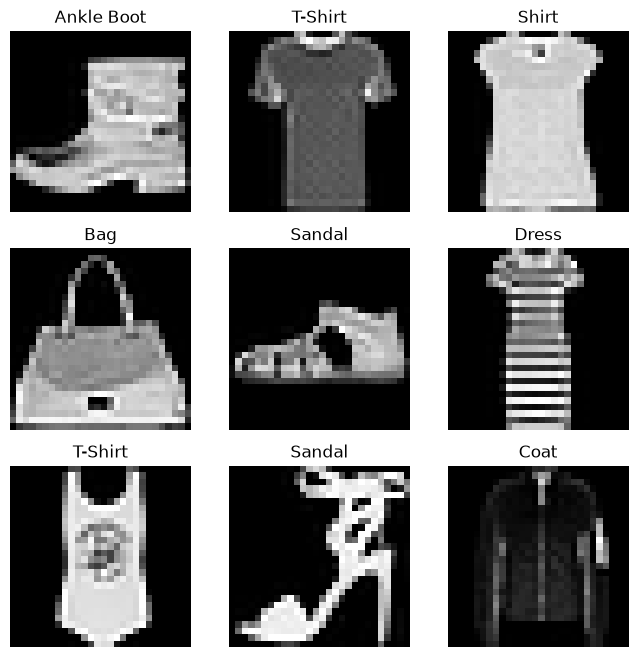

In [98]:
import matplotlib.pyplot as plt
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()


Creating a Custom Dataset for your files
========================================

A custom Dataset class must implement three functions:
[\_\_init\_\_]{.title-ref}, [\_\_len\_\_]{.title-ref}, and
[\_\_getitem\_\_]{.title-ref}. Take a look at this implementation; the
FashionMNIST images are stored in a directory `img_dir`, and their
labels are stored separately in a CSV file `annotations_file`.


`__init__`
==========

The `__init__` function is run once when instantiating the Dataset
object. We initialize the directory containing the images, the
annotations file, and both transforms (covered in more detail in the
next section).

The labels.csv file looks like: :

    tshirt1.jpg, 0
    tshirt2.jpg, 0
    ......
    ankleboot999.jpg, 9

`__len__`
=========

The `__len__` function returns the number of samples in our dataset.


`__getitem__`
=============

The `__getitem__` function loads and returns a sample from the dataset
at the given index `idx`. Based on the index, it identifies the image\'s
location on disk, converts that to a tensor using `read_image`,
retrieves the corresponding label from the csv data in
`self.img_labels`, calls the transform functions on them (if
applicable), and returns the tensor image and corresponding label in a
tuple.


In [95]:

#

import random

def data_loader(data, batch_size=32, shuffle=False):
    if batch_size <= 0:
         raise ValueError("batch_size must be 1 or greater.")

    dataset = data.clone() if shuffle else data

    if shuffle:
        random.shuffle(dataset)

    for i in range(0, len(dataset), batch_size):
        yield dataset[i : i + batch_size]




In [96]:
x = torch.arange(1,100)
for k in data_loader(x,2,shuffle=True):
    print(k)

tensor([1, 2])
tensor([2, 4])
tensor([5, 3])
tensor([5, 6])
tensor([1, 6])
tensor([10,  9])
tensor([6, 3])
tensor([ 2, 10])
tensor([9, 2])
tensor([6, 6])
tensor([ 3, 12])
tensor([18, 22])
tensor([15, 16])
tensor([23,  7])
tensor([21, 14])
tensor([11,  8])
tensor([30, 11])
tensor([27, 20])
tensor([ 9, 29])
tensor([19,  4])
tensor([33,  4])
tensor([19, 18])
tensor([26, 41])
tensor([31, 10])
tensor([21, 42])
tensor([17, 52])
tensor([2, 9])
tensor([20, 31])
tensor([ 6, 48])
tensor([11, 27])
tensor([17, 60])
tensor([52,  7])
tensor([34,  7])
tensor([18, 45])
tensor([18, 16])
tensor([61, 30])
tensor([55, 36])
tensor([56, 63])
tensor([14, 22])
tensor([44, 77])
tensor([61,  6])
tensor([76, 51])
tensor([26, 85])
tensor([28, 33])
tensor([64, 43])
tensor([ 9, 40])
tensor([14, 39])
tensor([55, 15])
tensor([94, 88])
tensor([42])


In [101]:
a,b=training_data[0]

In [134]:
batch_size = 64

df_train = DataLoader(training_data,batch_size=batch_size,pin_memory=True)
df_test = DataLoader(test_data,batch_size=batch_size,pin_memory=True)


In [121]:
from torch import nn
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork,self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )


    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [144]:
fashion_model = NeuralNetwork().to(device)




In [145]:
print(fashion_model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [140]:
criterion = nn.CrossEntropyLoss()  # loss function
optimizer = torch.optim.Adam(fashion_model.parameters(), lr=0.1)  # optimizer

60000

In [135]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


In [141]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        y_hat = model(X)
        loss = loss_fn(y_hat,y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if batch%100 == 0:
            loss = loss.item()
            current = (batch+1)*len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")



In [143]:
def train2(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [142]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train(df_train, fashion_model, criterion, optimizer)

Epoch 1
-------------------------------
loss: 2.304351  [   64/60000]
loss: 2.173355  [ 6464/60000]
loss: 2.323144  [12864/60000]
loss: 2.297758  [19264/60000]
loss: 2.296625  [25664/60000]
loss: 2.315584  [32064/60000]
loss: 2.276116  [38464/60000]
loss: 2.295080  [44864/60000]
loss: 2.263031  [51264/60000]
loss: 2.310354  [57664/60000]
Epoch 2
-------------------------------
loss: 2.810458  [   64/60000]
loss: 2.300677  [ 6464/60000]
loss: 2.327838  [12864/60000]
loss: 2.294520  [19264/60000]
loss: 2.279219  [25664/60000]
loss: 2.317207  [32064/60000]
loss: 2.309319  [38464/60000]
loss: 2.256540  [44864/60000]
loss: 2.305947  [51264/60000]
loss: 2.328337  [57664/60000]
Epoch 3
-------------------------------
loss: 2.333749  [   64/60000]
loss: 2.300736  [ 6464/60000]
loss: 2.327266  [12864/60000]
loss: 2.294363  [19264/60000]
loss: 2.277236  [25664/60000]
loss: 2.316530  [32064/60000]
loss: 2.309376  [38464/60000]
loss: 2.255938  [44864/60000]
loss: 2.306616  [51264/60000]
loss: 2.32

In [146]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train2(df_train, fashion_model, criterion, optimizer)

Epoch 1
-------------------------------
loss: 2.308478  [   64/60000]
loss: 2.314218  [ 6464/60000]
loss: 2.320933  [12864/60000]
loss: 2.325731  [19264/60000]
loss: 2.322473  [25664/60000]
loss: 2.320007  [32064/60000]
loss: 2.312191  [38464/60000]
loss: 2.315363  [44864/60000]
loss: 2.318227  [51264/60000]
loss: 2.323766  [57664/60000]
Epoch 2
-------------------------------
loss: 2.308478  [   64/60000]
loss: 2.314218  [ 6464/60000]
loss: 2.320933  [12864/60000]
loss: 2.325731  [19264/60000]
loss: 2.322473  [25664/60000]
loss: 2.320007  [32064/60000]
loss: 2.312191  [38464/60000]
loss: 2.315363  [44864/60000]
loss: 2.318227  [51264/60000]
loss: 2.323766  [57664/60000]
Epoch 3
-------------------------------
loss: 2.308478  [   64/60000]
loss: 2.314218  [ 6464/60000]
loss: 2.320933  [12864/60000]
loss: 2.325731  [19264/60000]
loss: 2.322473  [25664/60000]
loss: 2.320007  [32064/60000]
loss: 2.312191  [38464/60000]
loss: 2.315363  [44864/60000]
loss: 2.318227  [51264/60000]
loss: 2.32

### Evaluation on the Test Set

- Switching to evaluation mode with `torch.no_grad()` to disable gradient tracking.

In [150]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
         for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss+=loss_fn(pred,y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(
        f"Test Error: \n Accuracy: {(100 * correct):>0.1f}%, Avg loss: {test_loss:>8f} \n"
    )



In [151]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train2(df_train, fashion_model, criterion, optimizer)
    test(df_test, fashion_model, criterion)
print("Done!")

Epoch 1
-------------------------------
loss: 2.308478  [   64/60000]
loss: 2.314218  [ 6464/60000]
loss: 2.320933  [12864/60000]
loss: 2.325731  [19264/60000]
loss: 2.322473  [25664/60000]
loss: 2.320007  [32064/60000]
loss: 2.312191  [38464/60000]
loss: 2.315363  [44864/60000]
loss: 2.318227  [51264/60000]
loss: 2.323766  [57664/60000]
Test Error: 
 Accuracy: 8.2%, Avg loss: 2.319658 

Epoch 2
-------------------------------
loss: 2.308478  [   64/60000]
loss: 2.314218  [ 6464/60000]
loss: 2.320933  [12864/60000]
loss: 2.325731  [19264/60000]
loss: 2.322473  [25664/60000]
loss: 2.320007  [32064/60000]
loss: 2.312191  [38464/60000]
loss: 2.315363  [44864/60000]
loss: 2.318227  [51264/60000]
loss: 2.323766  [57664/60000]
Test Error: 
 Accuracy: 8.2%, Avg loss: 2.319658 

Epoch 3
-------------------------------
loss: 2.308478  [   64/60000]
loss: 2.314218  [ 6464/60000]
loss: 2.320933  [12864/60000]
loss: 2.325731  [19264/60000]
loss: 2.322473  [25664/60000]
loss: 2.320007  [32064/60000